<a href="https://colab.research.google.com/github/Ayush-hm/AI-Toolbox/blob/main/%20AIS_SPOOFING_DETECTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

In [4]:
# ============================================================
# AIS VESSEL SPOOFING DETECTION — ISOLATION FOREST
# Detects sudden trajectory changes as spoofing candidates
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from math import radians, sin, cos, sqrt, atan2
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv('/content/ais-2023-01-01.csv')

# Rename columns to match the expected format in engineer_trajectory_features
rename_map = {
    'mmsi': 'MMSI',
    'base_date_time': 'TSTAMP',
    'latitude': 'LAT',
    'longitude': 'LON',
    'sog': 'SOG',
    'cog': 'COG',
    'nav_status': 'NAVSTAT',
    'imo': 'IMO'
}

# Check if 'true_heading' exists in the original columns before renaming
# If it exists, add it to the rename map. If not, 'HEADING' will be handled separately.
if 'true_heading' in df.columns:
    rename_map['true_heading'] = 'HEADING'

df = df.rename(columns=rename_map)

# Ensure 'HEADING' column exists. If 'true_heading' was not in the original CSV,
# 'HEADING' would be missing after the rename. Add it with NaN values in such a case.
if 'HEADING' not in df.columns:
    df['HEADING'] = np.nan # Use NaN for missing heading data

# Ensure 'NAVSTAT' column exists. If 'nav_status' was not in the original CSV,
# 'NAVSTAT' would be missing after the rename. Add it with NaN values in such a case.
if 'NAVSTAT' not in df.columns:
    df['NAVSTAT'] = np.nan # Use NaN for missing navigation status data

# Convert TSTAMP to datetime objects
df['TSTAMP'] = pd.to_datetime(df['TSTAMP'], format='mixed')

# Add 'label' and 'attack_type' columns with default values, as they are used in the pipeline
# These columns are typically part of synthetic datasets for evaluation, not raw AIS data.
if 'label' not in df.columns:
    df['label'] = 0  # Default to 0 (no spoofing detected) for raw data
if 'attack_type' not in df.columns:
    df['attack_type'] = 'none' # Default to 'none' for raw data

In [7]:
# ─────────────────────────────────────────────
# 2. HAVERSINE DISTANCE
# ─────────────────────────────────────────────

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

In [8]:

# ─────────────────────────────────────────────
# 3. FEATURE ENGINEERING
#    Detects sudden changes in trajectory
# ─────────────────────────────────────────────

def engineer_trajectory_features(df):
    """
    Computes per-message delta features capturing sudden trajectory changes.
    All features are computed within each vessel's sorted message sequence.
    """
    df = df.sort_values(['MMSI', 'TSTAMP']).copy()
    features = []

    for mmsi, grp in df.groupby('MMSI'):
        g = grp.reset_index(drop=True)

        for i in range(len(g)):
            if i == 0:
                features.append({
                    'MMSI'                : mmsi,
                    'TSTAMP'              : g.loc[i, 'TSTAMP'],
                    'LAT'                 : g.loc[i, 'LAT'],
                    'LON'                 : g.loc[i, 'LON'],
                    # All deltas are 0 for first message
                    'time_gap_sec'        : 0,
                    'delta_pos_km'        : 0,
                    'implied_speed_kt'    : g.loc[i, 'SOG'],
                    'sog_vs_implied'      : 0,
                    'speed_delta'         : 0,
                    'cog_delta'           : 0,
                    'heading_cog_diff'    : abs(g.loc[i, 'HEADING'] - g.loc[i, 'COG']),
                    'navstat_inconsistent': int(g.loc[i, 'NAVSTAT'] in [1, 5] and g.loc[i, 'SOG'] > 1.0),
                    'imo_missing'         : int(pd.isna(g.loc[i, 'IMO'])),
                    'label'               : g.loc[i, 'label'],
                    'attack_type'         : g.loc[i, 'attack_type'],
                })
                continue

            # Time gap
            t_gap = (g.loc[i, 'TSTAMP'] - g.loc[i-1, 'TSTAMP']).total_seconds()
            t_gap = max(t_gap, 1)  # avoid division by zero

            # Position jump
            dist_km = haversine_km(
                g.loc[i-1, 'LAT'], g.loc[i-1, 'LON'],
                g.loc[i,   'LAT'], g.loc[i,   'LON']
            )

            # Implied speed from actual position change
            implied_kt = (dist_km / 1.852) / (t_gap / 3600)

            # COG wrap-around safe delta
            cog_diff = abs(g.loc[i, 'COG'] - g.loc[i-1, 'COG'])
            cog_diff = min(cog_diff, 360 - cog_diff)

            # Heading vs COG divergence
            hdg_cog  = abs(g.loc[i, 'HEADING'] - g.loc[i, 'COG'])
            hdg_cog  = min(hdg_cog, 360 - hdg_cog)

            features.append({
                'MMSI'                : mmsi,
                'TSTAMP'              : g.loc[i, 'TSTAMP'],
                'LAT'                 : g.loc[i, 'LAT'],
                'LON'                 : g.loc[i, 'LON'],
                'time_gap_sec'        : t_gap,
                'delta_pos_km'        : dist_km,
                'implied_speed_kt'    : implied_kt,
                'sog_vs_implied'      : abs(g.loc[i, 'SOG'] - implied_kt),
                'speed_delta'         : abs(g.loc[i, 'SOG'] - g.loc[i-1, 'SOG']),
                'cog_delta'           : cog_diff,
                'heading_cog_diff'    : hdg_cog,
                'navstat_inconsistent': int(g.loc[i, 'NAVSTAT'] in [1, 5] and g.loc[i, 'SOG'] > 1.0),
                'imo_missing'         : int(pd.isna(g.loc[i, 'IMO'])),
                'label'               : g.loc[i, 'label'],
                'attack_type'         : g.loc[i, 'attack_type'],
            })

    return pd.DataFrame(features)

In [9]:
import logging

In [10]:
# ─────────────────────────────────────────────
# 4. ISOLATION FOREST MODEL
# ─────────────────────────────────────────────

FEATURE_COLS = [
    'time_gap_sec',
    'delta_pos_km',         # ← KEY: sudden position jump
    'implied_speed_kt',     # ← KEY: physically impossible speeds
    'sog_vs_implied',       # ← KEY: reported vs real speed mismatch
    'speed_delta',          # sudden acceleration
    'cog_delta',
    'heading_cog_diff',     # heading vs course divergence
    'navstat_inconsistent', # moored but moving
    'imo_missing',          # identity spoofing signal
]

def train_isolation_forest(feat_df, contamination=0.06):
    """
    Trains an Isolation Forest on normal trajectory features.
    contamination = expected fraction of anomalies (~spoof_rate).

    Returns: trained pipeline, predictions, anomaly scores
    """
    X = feat_df[FEATURE_COLS].fillna(0).values

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('iforest', IsolationForest(
            n_estimators   = 200,
            contamination  = contamination,
            max_samples     = 'auto',
            random_state   = 42,
            n_jobs         = -1
        ))
    ])

    pipe.fit(X)

    # predict: +1 = normal, -1 = anomaly
    preds  = pipe.predict(X)
    scores = pipe.decision_function(X)  # more negative = more anomalous

    return pipe, preds, scores


# ─────────────────────────────────────────────
# 5. VESSEL-LEVEL RISK SCORING
#    Aggregates message-level anomalies per vessel
# ─────────────────────────────────────────────

def vessel_risk_report(feat_df, preds, scores):
    """
    Groups anomalies by MMSI and assigns a risk score (0–100).
    A vessel with many flagged messages = high spoofing risk.
    """
    feat_df = feat_df.copy()
    feat_df['if_pred']  = preds   # -1 = anomaly, +1 = normal
    feat_df['if_score'] = scores  # lower = more anomalous

    report = feat_df.groupby('MMSI').agg(
        total_messages       = ('if_pred', 'count'),
        anomalous_messages   = ('if_pred', lambda x: (x == -1).sum()),
        mean_anomaly_score   = ('if_score', 'mean'),
        min_anomaly_score    = ('if_score', 'min'),  # worst single message
        max_cog_delta        = ('cog_delta', 'max'),
        max_pos_jump_km      = ('delta_pos_km', 'max'),
        max_speed_mismatch   = ('sog_vs_implied', 'max'),
        true_spoof_messages  = ('label', 'sum'),
    ).reset_index()

    # Risk score: % anomalous messages, scaled 0–100
    report['anomaly_rate_%'] = (
        report['anomalous_messages'] / report['total_messages'] * 100
    ).round(1)

    # Flag vessels where >10% of messages are anomalous
    report['SPOOFING_RISK'] = report['anomaly_rate_%'].apply(
        lambda x: 'HIGH' if x > 15 else ('MEDIUM' if x > 5 else 'LOW')
    )

    return report.sort_values('anomaly_rate_%', ascending=False)


# ─────────────────────────────────────────────
# 6. VISUALIZATION
# ─────────────────────────────────────────────

def plot_results(feat_df, preds, scores, report):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('AIS Vessel Spoofing Detection — Isolation Forest', fontsize=16, fontweight='bold')

    # ── Plot 1: Trajectory Map — normal vs anomalous points
    ax = axes[0, 0]
    normal  = feat_df[preds == 1]
    anomaly = feat_df[preds == -1]
    ax.scatter(normal['LON'],  normal['LAT'],  c='steelblue', s=4, alpha=0.3, label='Normal')
    ax.scatter(anomaly['LON'], anomaly['LAT'], c='red',       s=20, alpha=0.8, label='Anomaly (Spoofing Candidate)', zorder=5)
    ax.set_title('Vessel Trajectory Map — Flagged Points')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ── Plot 2: Anomaly Score Distribution
    ax = axes[0, 1]
    ax.hist(scores[preds == 1],  bins=50, alpha=0.6, color='steelblue', label='Normal')
    ax.hist(scores[preds == -1], bins=50, alpha=0.8, color='red',       label='Anomaly')
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Decision boundary')
    ax.set_title('Anomaly Score Distribution')
    ax.set_xlabel('Isolation Forest Score (lower = more anomalous)')
    ax.set_ylabel('Count')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # ── Plot 3: COG Delta vs Position Jump (key spoofing signals)
    ax = axes[1, 0]
    sc = ax.scatter(
        feat_df['cog_delta'],
        feat_df['delta_pos_km'],
        c=scores, cmap='RdYlGn', s=8, alpha=0.5
    )
    ax.set_title('Course Change vs Position Jump\n(Red = Anomalous)')
    ax.set_xlabel('COG Delta (degrees)')
    ax.set_ylabel('Position Jump (km)')
    plt.colorbar(sc, ax=ax, label='Anomaly Score')
    ax.grid(True, alpha=0.3)

    # ── Plot 4: Vessel Risk Report — Top 15 vessels
    ax = axes[1, 1]
    top15 = report.head(15)
    colors = ['#d32f2f' if r == 'HIGH' else '#f57c00' if r == 'MEDIUM' else '#388e3c'
              for r in top15['SPOOFING_RISK']]
    bars = ax.barh(top15['MMSI'].astype(str).str[-6:], top15['anomaly_rate_%'], color=colors)
    ax.set_title('Top 15 Vessels by Anomaly Rate')
    ax.set_xlabel('Anomaly Rate (%)')
    ax.set_ylabel('MMSI (last 6 digits)')
    high_p   = mpatches.Patch(color='#d32f2f', label='HIGH risk')
    medium_p = mpatches.Patch(color='#f57c00', label='MEDIUM risk')
    low_p    = mpatches.Patch(color='#388e3c', label='LOW risk')
    ax.legend(handles=[high_p, medium_p, low_p], fontsize=8)
    ax.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.savefig('ais_isolation_forest_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✅ Plot saved: ais_isolation_forest_results.png")


# ─────────────────────────────────────────────
# 7. MAIN — Run Full Pipeline
# ─────────────────────────────────────────────
def main():
    # Ensure logging is configured only once, and correctly
    for handler in logging.root.handlers[:]:
        logging.root.removeHandler(handler)
    logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s', force=True)

    logging.info("=" * 55)
    logging.info("  AIS SPOOFING DETECTION — ISOLATION FOREST PIPELINE")
    logging.info("=" * 55)

    # Step 1: Load data
    logging.info("\n[1/5] Loading AIS data from CSV...")
    raw_df = df.copy()
    logging.info(f"      → {len(raw_df):,} messages across {raw_df['MMSI'].nunique()} vessels")

    # Step 2: Feature engineering
    logging.info("\n[2/5] Engineering trajectory features...")
    feat_df = engineer_trajectory_features(raw_df)
    logging.info(f"      → {len(FEATURE_COLS)} features: {FEATURE_COLS}")
    logging.info(f"      → Engineered features for {len(feat_df['MMSI'].unique())} vessels")

    # Step 3: Train Isolation Forest
    logging.info("\n[3/5] Training Isolation Forest (contamination=0.06)...")
    model, preds, scores = train_isolation_forest(feat_df, contamination=0.06)
    n_flagged = (preds == -1).sum()
    logging.info(f"      → {n_flagged} messages flagged as anomalous ({n_flagged/len(preds)*100:.1f}%)")

    # Step 4: Evaluation against ground truth labels (if available)
    # Note: For raw AIS data without injected labels, this evaluation might not be meaningful.
    # The 'label' column is assumed to be 0 for all entries if not present in the original CSV.
    logging.info("\n[4/5] Evaluation against ground truth labels (if available)...")
    from sklearn.metrics import classification_report, confusion_matrix

    y_true = feat_df['label'].values
    y_pred = (preds == -1).astype(int)  # -1 → 1 (anomaly)

    logging.info("\nClassification Report:")
    logging.info(classification_report(y_true, y_pred, target_names=['Normal', 'Spoofing']))

    cm = confusion_matrix(y_true, y_pred)
    logging.info(f"Confusion Matrix:\n  TN={cm[0,0]}  FP={cm[0,1]}\n  FN={cm[1,0]}  TP={cm[1,1]}")

    # Step 5: Vessel-level risk report
    logging.info("\n[5/5] Generating vessel risk report...")
    report = vessel_risk_report(feat_df, preds, scores)
    logging.info("\nTop 10 Highest-Risk Vessels:")
    logging.info(report[['MMSI', 'total_messages', 'anomalous_messages',
                  'anomaly_rate_%', 'max_pos_jump_km',
                  'max_cog_delta', 'SPOOFING_RISK']].head(10).to_string(index=False))

    # Step 6: Plot
    logging.info("\n[Plotting results...]")
    plot_results(feat_df, preds, scores, report)

    logging.info("\n✅ Pipeline complete.")
    logging.info(f"   HIGH risk vessels : {(report['SPOOFING_RISK'] == 'HIGH').sum()}")
    logging.info(f"   MEDIUM risk vessels: {(report['SPOOFING_RISK'] == 'MEDIUM').sum()}")
    logging.info(f"   LOW risk vessels  : {(report['SPOOFING_RISK'] == 'LOW').sum()}")

INFO: =======================================================
INFO:   AIS SPOOFING DETECTION — ISOLATION FOREST PIPELINE
INFO: =======================================================
INFO: 
[1/5] Loading AIS data from CSV...
INFO:       → 103,448 messages across 12390 vessels
INFO: 
[2/5] Engineering trajectory features...
INFO:       → 9 features: ['time_gap_sec', 'delta_pos_km', 'implied_speed_kt', 'sog_vs_implied', 'speed_delta', 'cog_delta', 'heading_cog_diff', 'navstat_inconsistent', 'imo_missing']
INFO:       → Engineered features for 12390 vessels
INFO: 
[3/5] Training Isolation Forest (contamination=0.06)...
INFO:       → 6207 messages flagged as anomalous (6.0%)
INFO: 
[4/5] Evaluation against ground truth labels (if available)...
INFO: 
Classification Report:
INFO:               precision    recall  f1-score   support

      Normal       1.00      0.94      0.97    103448
    Spoofing       0.00      0.00      0.00         0

    accuracy                           0.94    103

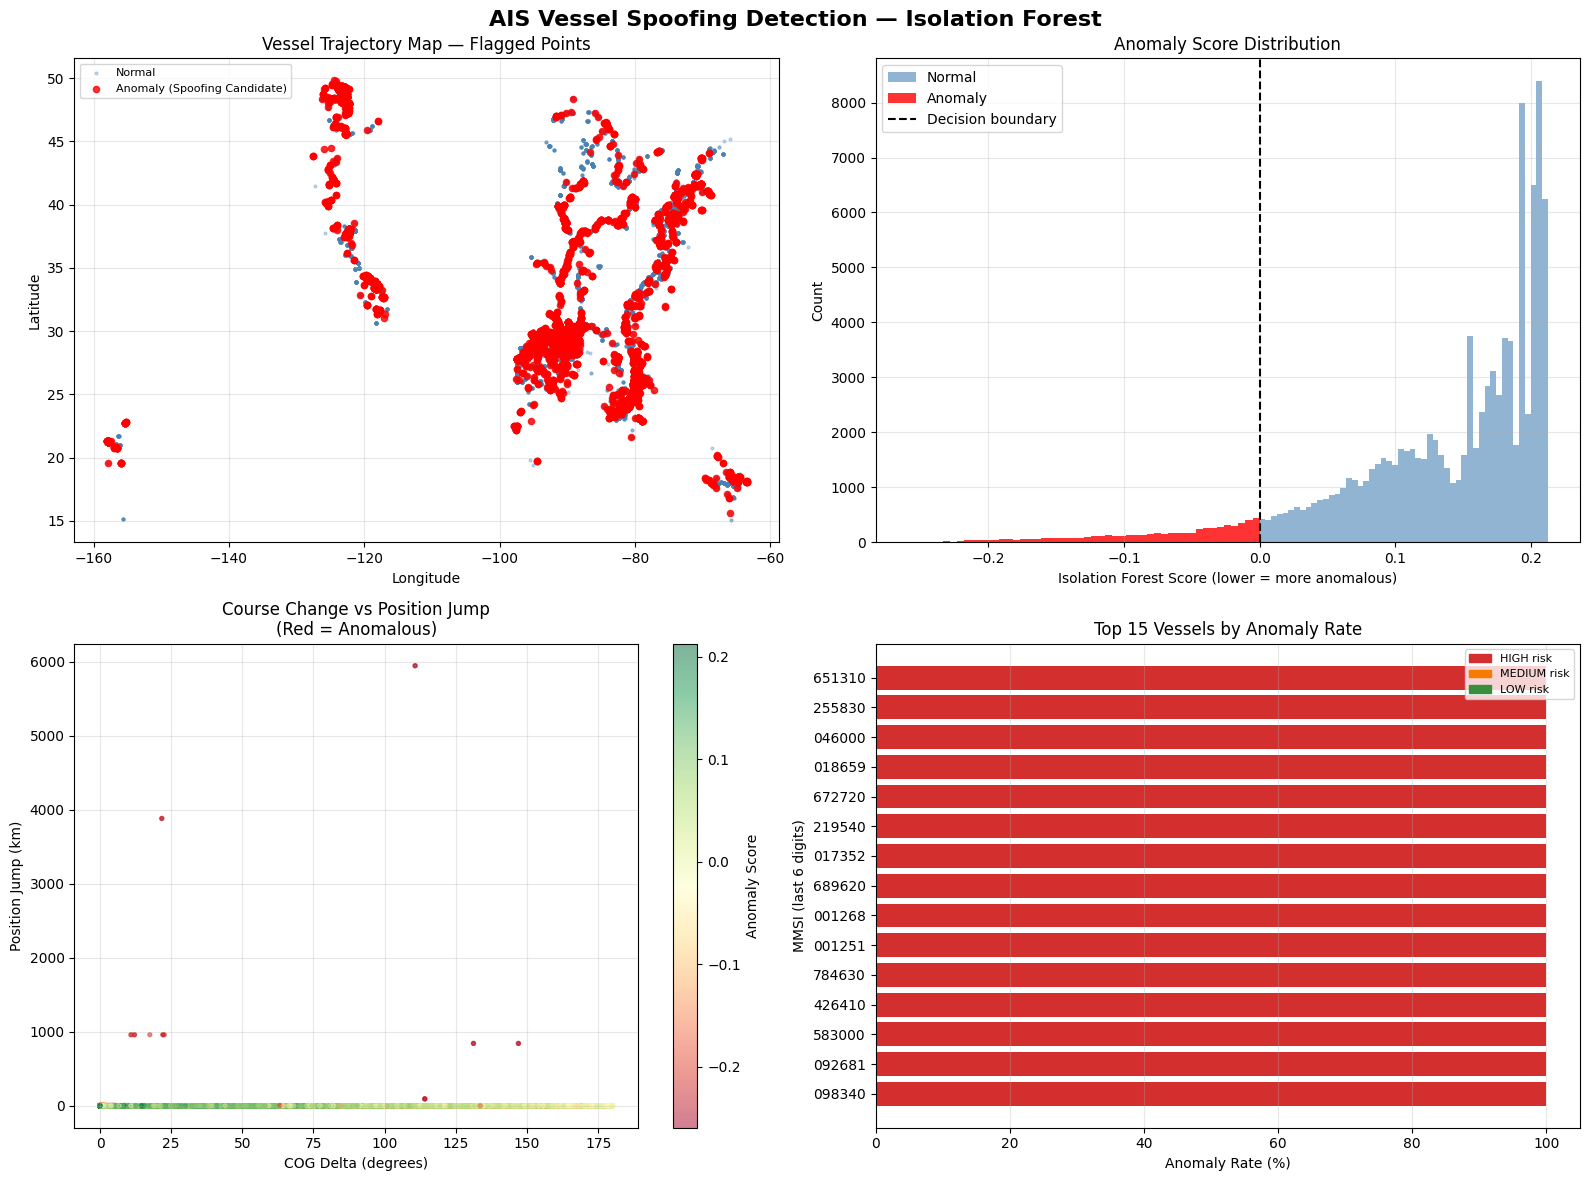

INFO: 
✅ Pipeline complete.
INFO:    HIGH risk vessels : 1399
INFO:    MEDIUM risk vessels: 668
INFO:    LOW risk vessels  : 10323



✅ Plot saved: ais_isolation_forest_results.png


In [11]:
main()